# Total Variation Divergence 的图像直觉

设两个连续型分布的概率密度函数分别为：

$$
p(x), \quad q(x)
$$

它们的 **Total Variation Divergence** 定义为：

$$
D_{TV}(P,Q)=\frac{1}{2}\int_{-\infty}^{\infty}|p(x)-q(x)|\,dx
$$

---

## 1. 为什么连续型情形也能理解

虽然对连续型随机变量来说，单个点的概率都是 0，但一个很小区间 $[x,x+dx]$ 上的概率近似为：

$$
P([x,x+dx])\approx p(x)\,dx,\qquad Q([x,x+dx])\approx q(x)\,dx
$$

所以在这个小区间上的概率差近似为：

$$
(p(x)-q(x))\,dx
$$

这说明，连续情形里比较的不是“单点概率”，而是**所有微小区间上的概率质量差**。

---

## 2. 图像上的直觉

当某些区域上有：

$$
p(x)>q(x)
$$

说明分布 $P$ 在这些地方比 $Q$ **多出一些概率质量**。

当另一些区域上有：

$$
q(x)>p(x)
$$

说明分布 $Q$ 在这些地方比 $P$ **多出一些概率质量**。

因此：

$$
\int |p(x)-q(x)|\,dx
$$

表示把两条密度曲线之间的“竖直差”在整个横轴上全部累加起来，也就是：

- $p(x)>q(x)$ 时的那部分面积
- 加上 $q(x)>p(x)$ 时的那部分面积

---

## 3. 为什么前面要乘 $\frac{1}{2}$

因为 $p(x),q(x)$ 都是概率密度函数，所以总面积都等于 1：

$$
\int p(x)\,dx = \int q(x)\,dx = 1
$$

所以：

$$
\int (p(x)-q(x))\,dx = 0
$$

这意味着：

- $p$ 高于 $q$ 的总面积
- 恰好等于 $q$ 高于 $p$ 的总面积

于是：

$$
\int |p(x)-q(x)|\,dx
$$

实际上把“差异面积”算了两遍，所以真正的总变差距离应为：

$$
D_{TV}(P,Q)=\frac{1}{2}\int |p(x)-q(x)|\,dx
$$

---

## 4. 等价理解

令

$$
A=\{x:\ p(x)\ge q(x)\}
$$

则在集合 $A$ 上，$P$ 比 $Q$ 多出来的总概率质量为：

$$
P(A)-Q(A)=\int_A (p(x)-q(x))\,dx
$$

而总变差距离恰好等于这个“最大能多出来的概率质量”：

$$
D_{TV}(P,Q)=\sup_B |P(B)-Q(B)|
$$

并且有：

$$
D_{TV}(P,Q)=\int_A (p(x)-q(x))\,dx
=\frac{1}{2}\int |p(x)-q(x)|\,dx
$$

---

## 5. 图像结论

所以从图像上看：

$$
D_{TV}(P,Q)
$$

就是 **两条密度曲线之间夹出来的总面积的一半**。

也可以理解为：

> 把分布 $P$ 变成分布 $Q$ 时，需要“搬运”的总概率质量。

Area where p(x) > q(x): 0.451462
Area where q(x) > p(x): 0.451422
Integral of |p(x)-q(x)|: 0.902884
TV divergence: 0.451442


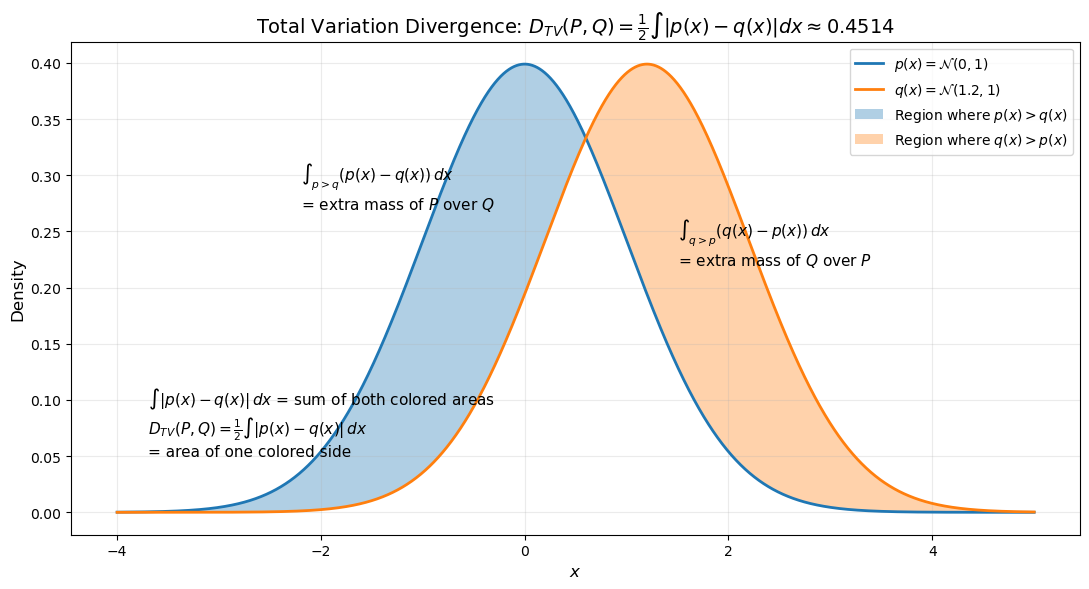

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 1. 定义两个连续型分布的密度函数
# ================================
# 这里选两个正态分布：
#
#   p(x) = N(0, 1)
#   q(x) = N(1.2, 1)
#
# 它们有重叠，但不完全一样，很适合用来展示
# Total Variation Divergence 的面积直觉。

def normal_pdf(x, mu, sigma):
    return 1.0 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# 横轴取值范围
x = np.linspace(-4, 5, 3000)

# 两个密度
p = normal_pdf(x, mu=0.0, sigma=1.0)
q = normal_pdf(x, mu=1.2, sigma=1.0)

# ================================
# 2. 数值计算 TV divergence
# ================================
# 根据定义：
#
#   D_TV(P, Q) = 1/2 * \int |p(x) - q(x)| dx
#
# 这里用梯形积分 np.trapz 做数值近似。

tv = 0.5 * np.trapezoid(np.abs(p - q), x)

# 分别标记两个区域：
# - p >= q 的地方
# - q > p 的地方
mask_p_gt_q = p >= q
mask_q_gt_p = q > p

# 额外算出两边着色面积，帮助理解
area_p_gt_q = np.trapezoid(np.maximum(p - q, 0), x)
area_q_gt_p = np.trapezoid(np.maximum(q - p, 0), x)


print(f"Area where p(x) > q(x): {area_p_gt_q:.6f}")
print(f"Area where q(x) > p(x): {area_q_gt_p:.6f}")
print(f"Integral of |p(x)-q(x)|: {np.trapezoid(np.abs(p-q), x):.6f}")
print(f"TV divergence: {tv:.6f}")

# ================================
# 3. 画图
# ================================
plt.figure(figsize=(11, 6))

# 画两条密度曲线
plt.plot(x, p, linewidth=2, label=r"$p(x)=\mathcal{N}(0,1)$")
plt.plot(x, q, linewidth=2, label=r"$q(x)=\mathcal{N}(1.2,1)$")

# 用颜色填充 p(x) > q(x) 的区域
# 这块表示：P 相对 Q 多出来的概率质量
plt.fill_between(
    x, p, q,
    where=mask_p_gt_q,
    interpolate=True,
    alpha=0.35,
    label=r"Region where $p(x) > q(x)$"
)

# 用颜色填充 q(x) > p(x) 的区域
# 这块表示：Q 相对 P 多出来的概率质量
plt.fill_between(
    x, p, q,
    where=mask_q_gt_p,
    interpolate=True,
    alpha=0.35,
    label=r"Region where $q(x) > p(x)$"
)

# 图标题写出定义
plt.title(
    rf"Total Variation Divergence: "
    rf"$D_{{TV}}(P,Q)=\frac{{1}}{{2}}\int |p(x)-q(x)|dx \approx {tv:.4f}$",
    fontsize=14
)

plt.xlabel(r"$x$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(alpha=0.25)
plt.legend()

# ================================
# 4. 图中添加解释文字
# ================================
# 左边区域：p(x) > q(x)
plt.text(
    -2.2, 0.27,
    r"$\int_{p>q}(p(x)-q(x))\,dx$" "\n"
    r"= extra mass of $P$ over $Q$",
    fontsize=11
)

# 右边区域：q(x) > p(x)
plt.text(
    1.5, 0.22,
    r"$\int_{q>p}(q(x)-p(x))\,dx$" "\n"
    r"= extra mass of $Q$ over $P$",
    fontsize=11
)

# 底部加总结
plt.text(
    -3.7, 0.05,
    r"$\int |p(x)-q(x)|\,dx$ = sum of both colored areas" "\n"
    r"$D_{TV}(P,Q)=\frac{1}{2}\int |p(x)-q(x)|\,dx$"
    "\n"
    r"= area of one colored side",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 一句话记忆

对于连续型分布，

$$
D_{TV}(P,Q)
$$

就是两条概率密度曲线之间夹出来的面积的一半。